# HMM Bias Comparison

In [1]:
# Whether to recompute results
RERUN = false

false

In [2]:
using StatsPlots, StatsPlots.PlotMeasures
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl")

write_EM_to_mat (generic function with 1 method)

In [3]:
fns_hmm = [
    ("hmm_leaf", run_hmm_leaf),
    ("hmm_leaf_γ2", run_hmm_leaf_γ2),
    ("hmm_leaf_retainbelief", run_hmm_leaf_retainbelief),
    ("hmm_leaf_stay", run_hmm_leaf_stay),
    ("hmm_leaf_turn", run_hmm_leaf_turn),
    ("hmm_leaf_spatial", run_hmm_leaf_spatial),
    ("hmm_leaf_leafspatial", run_hmm_leaf_leafspatial),
    ("hmm_leaf_leafturn", run_hmm_leaf_leafturn),
]
fns_hmm_stay = [
    ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2),
    ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief),
    ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial),
    ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial),
    ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn),
    ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial),
    ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn),
]
fns_hmm_γ2 = [
    ("hmm_leaf_turn_γ2", run_hmm_leaf_turn_γ2),
    ("hmm_leaf_spatial_γ2", run_hmm_leaf_spatial_γ2),
    ("hmm_leaf_turn_leafspatial_γ2", run_hmm_leaf_turn_leafspatial_γ2),
    ("hmm_leaf_turn_leafturn_γ2", run_hmm_leaf_turn_leafturn_γ2),
    ("hmm_leaf_spatial_leafspatial_γ2", run_hmm_leaf_spatial_leafspatial_γ2),
    ("hmm_leaf_spatial_leafturn_γ2", run_hmm_leaf_spatial_leafturn_γ2),
]
fns_hmm_stay_γ2 = [
    ("hmm_leaf_stay_turn_γ2", run_hmm_leaf_stay_turn_γ2),
    ("hmm_leaf_stay_spatial_γ2", run_hmm_leaf_stay_spatial_γ2),
    ("hmm_leaf_stay_turn_leafspatial_γ2", run_hmm_leaf_stay_turn_leafspatial_γ2),
    ("hmm_leaf_stay_turn_leafturn_γ2", run_hmm_leaf_stay_turn_leafturn_γ2),
    ("hmm_leaf_stay_spatial_leafspatial_γ2", run_hmm_leaf_stay_spatial_leafspatial_γ2),
    ("hmm_leaf_stay_spatial_leafturn_γ2", run_hmm_leaf_stay_spatial_leafturn_γ2),
]
fns_hmm_depletion = [
    ("hmm_leaf_depletion", run_hmm_leaf_depletion),
    ("hmm_leaf_γ2_depletion", run_hmm_leaf_γ2_depletion),
    ("hmm_leaf_retainbelief_depletion", run_hmm_leaf_retainbelief_depletion),
    ("hmm_leaf_stay_depletion", run_hmm_leaf_stay_depletion),
    ("hmm_leaf_turn_depletion", run_hmm_leaf_turn_depletion),
    ("hmm_leaf_spatial_depletion", run_hmm_leaf_spatial_depletion),
    ("hmm_leaf_leafspatial_depletion", run_hmm_leaf_leafspatial_depletion),
    ("hmm_leaf_leafturn_depletion", run_hmm_leaf_leafturn_depletion),
]
fns_hmm_stay_depletion = [
    ("hmm_leaf_stay_γ2_depletion", run_hmm_leaf_stay_γ2_depletion),
    ("hmm_leaf_stay_retainbelief_depletion", run_hmm_leaf_stay_retainbelief_depletion),
    ("hmm_leaf_stay_turn_depletion", run_hmm_leaf_stay_turn_depletion),
    ("hmm_leaf_stay_spatial_depletion", run_hmm_leaf_stay_spatial_depletion),
    ("hmm_leaf_stay_turn_leafspatial_depletion", run_hmm_leaf_stay_turn_leafspatial_depletion),
    ("hmm_leaf_stay_turn_leafturn_depletion", run_hmm_leaf_stay_turn_leafturn_depletion),
    ("hmm_leaf_stay_spatial_leafspatial_depletion", run_hmm_leaf_stay_spatial_leafspatial_depletion),
    ("hmm_leaf_stay_spatial_leafturn_depletion", run_hmm_leaf_stay_spatial_leafturn_depletion),
]
fns_hmm_γ2_depletion = [
    ("hmm_leaf_turn_γ2_depletion", run_hmm_leaf_turn_γ2_depletion),
    ("hmm_leaf_spatial_γ2_depletion", run_hmm_leaf_spatial_γ2_depletion),
    ("hmm_leaf_turn_leafspatial_γ2_depletion", run_hmm_leaf_turn_leafspatial_γ2_depletion),
    ("hmm_leaf_turn_leafturn_γ2_depletion", run_hmm_leaf_turn_leafturn_γ2_depletion),
    ("hmm_leaf_spatial_leafspatial_γ2_depletion", run_hmm_leaf_spatial_leafspatial_γ2_depletion),
    ("hmm_leaf_spatial_leafturn_γ2_depletion", run_hmm_leaf_spatial_leafturn_γ2_depletion),
]
fns_hmm_stay_γ2_depletion = [
    ("hmm_leaf_stay_turn_γ2_depletion", run_hmm_leaf_stay_turn_γ2_depletion),
    ("hmm_leaf_stay_spatial_γ2_depletion", run_hmm_leaf_stay_spatial_γ2_depletion),
    ("hmm_leaf_stay_turn_leafspatial_γ2_depletion", run_hmm_leaf_stay_turn_leafspatial_γ2_depletion),
    ("hmm_leaf_stay_turn_leafturn_γ2_depletion", run_hmm_leaf_stay_turn_leafturn_γ2_depletion),
    ("hmm_leaf_stay_spatial_leafspatial_γ2_depletion", run_hmm_leaf_stay_spatial_leafspatial_γ2_depletion),
    ("hmm_leaf_stay_spatial_leafturn_γ2_depletion", run_hmm_leaf_stay_spatial_leafturn_γ2_depletion),
]
fns = vcat(fns_hmm, fns_hmm_stay, fns_hmm_γ2, fns_hmm_stay_γ2);
# fns = fns_leaf

In [4]:
if RERUN
    for animal in animals
        for (fname, fn) in fns_leafbias
            results = fn(load_animal(animal, filepath))
            save("$(filepath)/results/hmm_biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)", results)
        end
    end
end

In [5]:
function load_hmm_results(animals, fns; rewscaled=true, depletion=true)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    if rewscaled
        add_rewscaled = "_rewscaled"
    else
        add_rewscaled = ""
    end
    if depletion
        add_depletion = "_depletion"
    else
        add_depletion = ""
    end
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/hmm_biases$(add_depletion)/$(fname)$(add_rewscaled)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)$(add_rewscaled)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_hmm_results (generic function with 1 method)

## HMM Depletion Model

We consider a *state* to be a particular assignment of reward probabilities to each of the 6 reward ports.

For example, one hypothetical state might be

$\text{state} = [p_1=0.3, p_2=0.5, p_3=0.4, p_4=0.4, p_5=0.8, p_6=0.9]$

In the HMM, we're modeling our *belief* about which of a number of discrete states we're currently in. These states correspond to the *contingencies* that are actually used to provide rewards for the rats. Our set of contingencies, $\phi$, is a subset 72 of these possible contingencies. 

We assume we are in 1 of these 72 contingencies on any given trial, but with some uncertainty about which of these states we're in. Our belief state, $\alpha$, is a probabilitiy distributon over these 72 contingencies. 

We're assuming any contingency can transition to any other contingency, with some fixed probability, or $\text{volatility}$. This volatility, while fixed, has to be inferred (and is a parameter we fit)

Key terms:
- $\phi$: Set of possible contingencies (72 x 6)
- $\alpha$: Agent's belief state (1 x 72)
- $\text{volatility}$: Probability of contingency change each trial
- $\text{depletion factor}$: Fraction of value retained when remaining at the same leaf for multiple trials
So on any given trial, we can combine our belief state $\alpha$ with the set of contingencies $\phi$ to find our expected probability of reward at each of the six ports:

\begin{equation}
Q = \alpha * \phi
\end{equation}

At the end of each trial, we observe an outcome. We want to update $\alpha$ based on the probability of that outcome for each contingency.

If the outcome was positive, the probability of that the value of $\phi$ for that contingency and leaf, times $\text{df}^k$ where $\text{df}$ is the depletion factor, and $k$ is the depletion counter for that leaf,  and so $\alpha_i \leftarrow \alpha_i \phi_{ij} * \text{df}^k$ for contingency $i$ and leaf $j$

Finally, if no stem switch occured, we increment the depletion counter for the observed leaf by 1, otherwise set all to 0.

If the outcome was negative, this becomes $\alpha_i \leftarrow \alpha_i (1 - \phi_{ij} * \text{df}^k)$

## Choice Simulation

We separately model **stem** and **leaf** choices.

**Stem choice** is a based on a single `Qstem` value for each of the 3 stems
- For the current stem, this is the reward of the upcoming leaf
- For the other two stems, this is the average reward of the two leaves

We model the choice as `softmax` of the three stems, which at simplest would be
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta \text{Qstem}_1}}{e^{\beta \text{Qstem}_1 + \beta \text{Qstem}_2 + \beta \text{Qstem}_3}}
\end{equation}

However, to allow for some additional flexibility, the current stem has a separate $\beta$ (inverse temperature) from the other two:
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta_\text{stay} \text{Qstem}_1}}{e^{\beta_{stay} \text{Qstem}_1 + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

(Here we're assuming stem 1 is the current stem)

## Overview of model biases

## Stay Bias

One straightforward change is to add an offset for how much better the reward needs to be at another stem for us to change. This is incorporated as a constant addition to the current stem, after $\beta_{stay}$:

\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1 + \text{stay}}}{e^{\beta_{stay} \text{Qstem}_1 + \text{stay} + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

Note that this is different from the separate $\beta_{go}$ and $\beta_{stay}$ terms: While inverse temperature affects the sharpness of the choice (how much of an effect a change of reward has), the $\text{stay}$ term instead changes the point at which *stay* vs. *go* is equally weighted.

## γ2

As mentioned earlier, $\text{Qstem}$ for the current stem is taken to be the upcoming leaf, ignoring the leaf we're leaving.

While empirically, the rats are primarily driven by the upcoming leaf, they probably don't entirely ignore the other leaf.

We can add a weight, $\gamma 2$, adjusting the balance between the current and upcoming leaf:

\begin{equation}
\text{Qstem} = \beta_\text{stay} * ((1 - \gamma 2) * Q_2 + \gamma 2 * Q_1) 
\end{equation}

Defaults to $\gamma = 0$, where weight is entirely derived from the upcoming leaf

## Retain Belief (across sessions)

At the start of a day, we assume rats place equal weight on all contingencies: $\alpha_n = 1/72$ for all $n$

However, what happens between sessions on the same day? By default, we're resetting the belief to the flat prior, but we can also incorporate some of the prior belief:

\begin{equation}
\alpha = (\text{retainbelief} * \alpha) + ((1 - \text{retainbelief}) * \alpha\text{Prior})
\end{equation}

Defaults to 0

## Reward Scaling and stay bias

Rewards are encoded in the data as 0 or 1. For consistency with the Q-learning model, we're going to rescale rewards to sit between -1 and 1

In practice, this means that after compuing Q-values as $Q=α*ϕ$, we'll rescale them as $Q_s = (Q + 1) / 2$

The one big effect of this is that it changes the inherent "stay bias", and so we really need to introduce the stay bias regressor for good fits (see separate document on reward scaling and stay bias)
- `stay`: Constant bias applied to current stem

Here, (compard to hmm_biases notebook) we're just going to include the stay bias w/ rescaled rewards from the start.

Below, we're plotting IAIC for the following models:

1. $\beta_\text{go}$ and $\beta_\text{stay}$
\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1}}{e^{\beta_{stay} \text{Qstem}_1 \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

2. $\beta_\text{go}$, $\beta_\text{stay}$, and $\text{staybias}$
\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1 + \text{stay}}}{e^{\beta_{stay} \text{Qstem}_1 + \text{stay} + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

In addition, we're either leaving reward as 0/1 or rescaling to -1/+1

Each animal has four bars, for the IAIC for each model. Lower IAIC is better here.

## Depletion

Depletion, as mentioned earlier, is a factor $d\in[0,1]$, such that the value of a leaf is scaled by $d^n$, where $n$ is the number of visits to that leaf since the last stem switch.

When not included, $d=1$, and no depletion occurs.

This should hopefully capture the switching behavior reasonably well in the depletion condition of the task.

We're going to start by checking the effect of depletion on a number of basic models: Does it consistently improve fit?

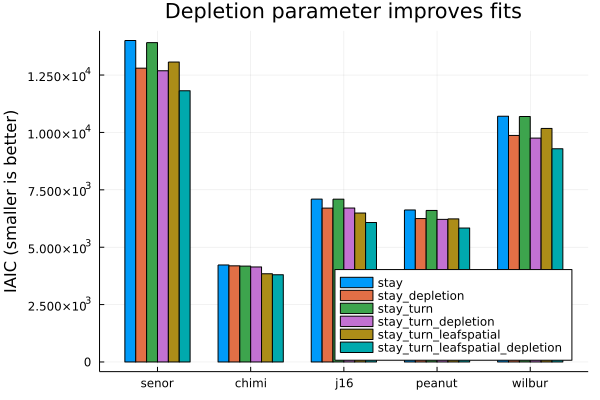

In [6]:
fns = vcat(fns_hmm[[4]], fns_hmm_depletion[[4]], fns_hmm_stay[[3]], fns_hmm_stay_depletion[[3]], fns_hmm_stay[[5]], fns_hmm_stay_depletion[[5]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="Depletion parameter improves fits",
)

We observe that in all four cases, adding a depletion parameter improves fit, so we'll focus on models of `stay` + `depletion`

For this basic model, let's also see if depletion fits look reasonable

hmm_leaf_stay_depletion
depletion_factor


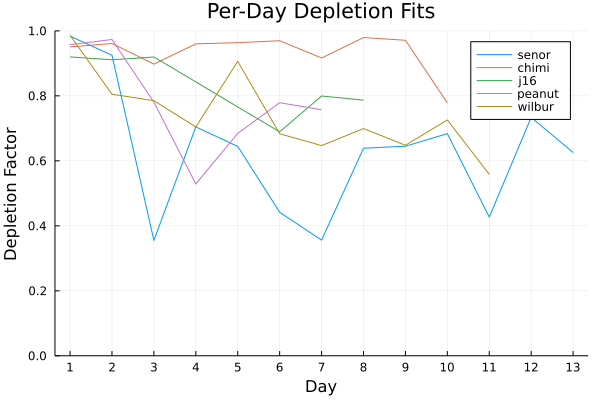

In [7]:
fn = fns_hmm_depletion[4]
varind = 6
(results, aics) = load_hmm_results(animals, [fn])
println(fn[1])
println(results[animals[1], fn[1]].varnames[varind])
p = plot()
for animal in animals
    x = results[animal, fn[1]].x[:, varind]
    x = 0.5.+0.5.*erf.(x ./ sqrt(2))
    plot!(x, label=animal)
end
xlabel!("Day")
ylabel!("Depletion Factor")
ylims!(0, 1)
xticks!(1:13)
title!("Per-Day Depletion Fits")

Unsurprisngly, they start off near-one (which is consistent for the previous task version) and quickly decrease

## γ2 and retainbelief

Next, let's take a look at a few independent choices and their effect on model fit:
- `γ2`: Weight applied to the leaf we're *leaving* on the current stem, versus leaf we're going to
- `retainbelief`: Do we allow a fraction of our belief state (contingency belief) to persist between sessions?

On the left, we see IAIC values for baseline (from here onwards baseline includes `stay_bias`), on the right bias terms

On the right, we see the improvement (decrease) in IAIC for the latter 2 versus baseline

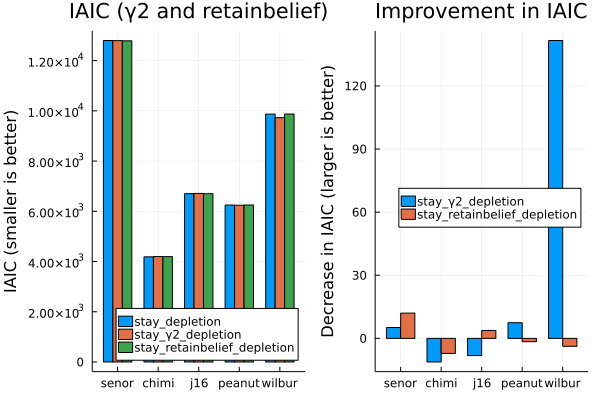

In [8]:
fns = vcat(fns_hmm_depletion[4], fns_hmm_stay_depletion[[1,2]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (γ2 and retainbelief)",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns[2:end]]),
    legend=(0.2, 0.5),
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2)

Results:
- `γ2` leads to a large improvement in wilbur (why?) but fairly inconsistent
- `retainbelief` isn't clear

## Stem Biases

### Turn Bias
Similar to the stay bias, we can include an offset for a particular turn direction (essentially, a bias for left/right)

So if we're at stem 1, our softmax is based on

\begin{align}
& \beta_\text{stay} \text{Qstem}_1 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_2 + \text{turnbias} \\
& \beta_\text{go} \text{Qstem}_3
\end{align}

Or if we're at stem 2, we instead add the same bias to stem 3

\begin{align}
& \beta_\text{go} \text{Qstem}_1 \\
& \beta_\text{stay} \text{Qstem}_2 + \text{staybias}\\
& \beta_\text{go} \text{Qstem}_3 + \text{turnbias} 
\end{align}

### Spatial Bias
We can also make this slightly more flexible, by varying the turn bias depending on our current stem.

So if we're at stem 1, we use one bias

\begin{align}
& \beta_\text{stay} \text{Qstem}_1 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_2 + \text{spatialbias}_2 \\
& \beta_\text{go} \text{Qstem}_3
\end{align}

Or if we're at stem 2, we add a different bias to stem 3

\begin{align}
& \beta_\text{go} \text{Qstem}_1 \\
& \beta_\text{stay} \text{Qstem}_2 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_3 + \text{spatialbias}_3
\end{align}

This approach adds three free parameters (one for each stem) versus one parameter for the simpler turn bias

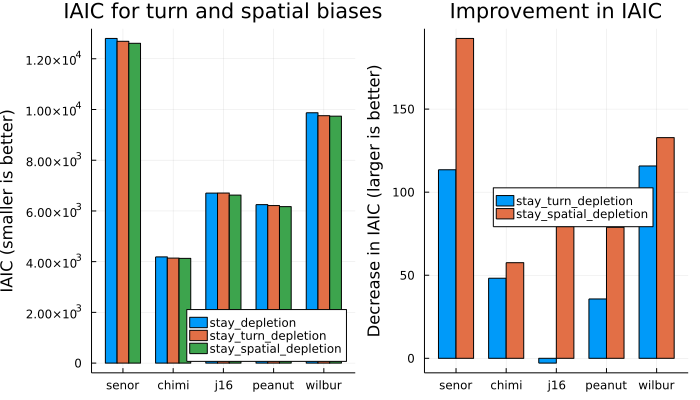

In [9]:
fns = vcat(fns_hmm_depletion[[4]], fns_hmm_stay_depletion[[3,4]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC for turn and spatial biases",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns[2:end]]),
    legend=(0.35, 0.5),
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2, size=(700, 400))

Unlike the non-depletion condition, we observe an improved fit for the three-parameter version in all animals, perhaps reflecting the increased dynamicism of the task

## Leaf Biases

### Leaf Turn Bias

Similar to our stem bias, we can bias leaf decisions (after a stem switch) either left/right with a single parameter

\begin{align}
& \beta_\text{leaf} \text{Qleaf}_1 + \text{leaf\_turn\_bias}\\
& \beta_\text{leaf} \text{Qleaf}_2
\end{align}

### Leaf Spatial Bias

We can again also parameterize this based on the stem:

That is, $\text{leaf_spatial_bias}$ has three parameters, one for each stem we're choosing between leaves on

Below, we're comparing to the `stay` model as baseline, and adding either the 1- or 3-parameter leaf bias, plus the 3-parameter stem bias

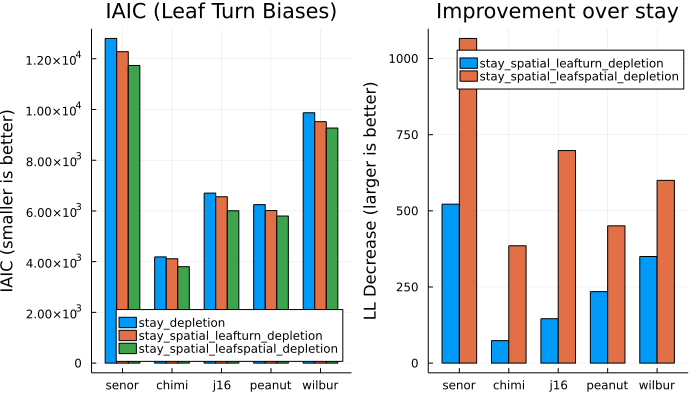

In [10]:
fns = vcat(fns_hmm_depletion[[4]], fns_hmm_stay_depletion[[8,7]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (Leaf Turn Biases)",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns[2:end]]),
    legend=(0.2,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay",
)
plot(p1, p2, size=(700, 400))

Addition of either bias leads to a huge model fit improvement - here again, the three-parameter version consistently provides a better fit

# Stem + Leaf Biases

Let's now compare the full set of 1 and 3 parameter biases for both stem and leaf choice

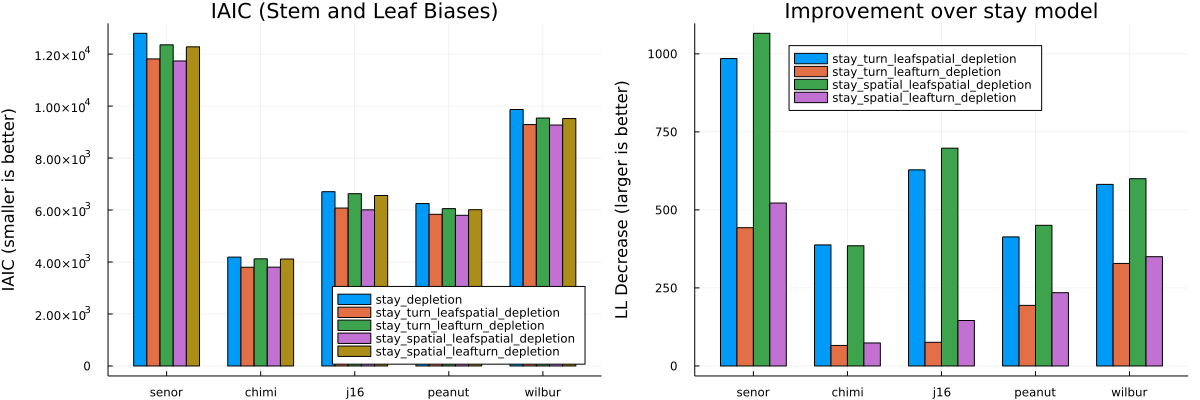

In [11]:
fns = vcat(fns_hmm_depletion[4], fns_hmm_stay_depletion[5:8])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (Stem and Leaf Biases)",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns[2:end]]),
    legend=(0.28,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400), left_margin = 5mm)

In combination, a 3-parameter stem bias + 3-parameter leaf bias seems to provide the best fit across the board

## Best-fitting model full results

In [12]:
animal = animals[1]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay_depletion[7]])
HTML(show_results(results[animal, fns_hmm_stay_depletion[7][1]];
    transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))], ["depletion_factor", x->0.5+0.5*erf(x / sqrt(2))]]))

senor


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"spatial_1\", \"spatial_2\", \"spatial_3\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"depletion_factor\", \"*volatility\", \"*depletion_factor\"]<br/></pre>β:<br/><pre> volati βgo   βstay βleaf stay_ spatia spatia spatia leaf_ leaf_s leaf_s deple *volati *deple <br/> <span style='color: red'>-1.91</span>  5.46  6.25  0.47  3.57  <span style='color: red'>-0.49</span>  <span style='color: red'>-0.84</span>  <span style='color: red'>-0.45</span>  0.32  <span style='color: red'>-0.75</span>  <span style='color: red'>-0.05</span>  0.41  0.03  0.66<br/>p:<br/> 0.01  0.01  0.01  0.72  0.01  0.02  0.01  0.01  0.37  0.01  0.49  0.03</pre>σ²:<br/><pre>  0.95    3.55   0.81   <span style='color: red'>-3.57</span>  <span style='color: red'>-0.48</span>  <span style='color: red'>-0.12</span>  <span style='color: red'>-0.62</span>  <span style='color: red'>-0.19</span>   0.66   0.58  <span style='color: red'>-0.07</span>   0.34<br/>  3.55   22.54   1.06  <span style='color: red'>-18.66</span>  <span style='color: red'>-3.81</span>  <span style='color: red'>-0.87</span>  <span style='color: red'>-2.6</span>   <span style='color: red'>-1.18</span>   3.56   2.7   <span style='color: red'>-0.05</span>   0.62<br/>  0.81    1.06   2.54   <span style='color: red'>-3.77</span>   0.67   0.24  <span style='color: red'>-0.94</span>  <span style='color: red'>-0.24</span>   0.97   0.45  <span style='color: red'>-0.06</span>   0.73<br/> <span style='color: red'>-3.57</span>  <span style='color: red'>-18.66</span>  <span style='color: red'>-3.77</span>   21.56   2.64  <span style='color: red'>-0.45</span>   3.08   1.66  <span style='color: red'>-5.3</span>   <span style='color: red'>-3.13</span>   0.33  <span style='color: red'>-1.85</span><br/> <span style='color: red'>-0.48</span>   <span style='color: red'>-3.81</span>   0.67    2.64   1.15   0.09   0.17   0.19  <span style='color: red'>-0.54</span>  <span style='color: red'>-0.5</span>    0.07  <span style='color: red'>-0.06</span><br/> <span style='color: red'>-0.12</span>   <span style='color: red'>-0.87</span>   0.24   <span style='color: red'>-0.45</span>   0.09   0.44  <span style='color: red'>-0.05</span>  <span style='color: red'>-0.12</span>   0.33  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.09</span>   0.23<br/> <span style='color: red'>-0.62</span>   <span style='color: red'>-2.6</span>   <span style='color: red'>-0.94</span>    3.08   0.17  <span style='color: red'>-0.05</span>   0.66   0.21  <span style='color: red'>-0.6</span>   <span style='color: red'>-0.34</span>   0.0   <span style='color: red'>-0.32</span><br/> <span style='color: red'>-0.19</span>   <span style='color: red'>-1.18</span>  <span style='color: red'>-0.24</span>    1.66   0.19  <span style='color: red'>-0.12</span>   0.21   0.18  <span style='color: red'>-0.48</span>  <span style='color: red'>-0.24</span>   0.02  <span style='color: red'>-0.15</span><br/>  0.66    3.56   0.97   <span style='color: red'>-5.3</span>   <span style='color: red'>-0.54</span>   0.33  <span style='color: red'>-0.6</span>   <span style='color: red'>-0.48</span>   1.63   0.86  <span style='color: red'>-0.13</span>   0.57<br/>  0.58    2.7    0.45   <span style='color: red'>-3.13</span>  <span style='color: red'>-0.5</span>   <span style='color: red'>-0.01</span>  <span style='color: red'>-0.34</span>  <span style='color: red'>-0.24</span>   0.86   0.66  <span style='color: red'>-0.07</span>   0.32<br/> <span style='color: red'>-0.07</span>   <span style='color: red'>-0.05</span>  <span style='color: red'>-0.06</span>    0.33   0.07  <span style='color: red'>-0.09</span>   0.0    0.02  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.07</span>   0.06  <span style='color: red'>-0.09</span><br/>  0.34    0.62   0.73   <span style='color: red'>-1.85</span>  <span style='color: red'>-0.06</span>   0.23  <spa

In [13]:
animal = animals[2]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay_depletion[7]])
HTML(show_results(results[animal, fns_hmm_stay_depletion[7][1]];
    transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))], ["depletion_factor", x->0.5+0.5*erf(x / sqrt(2))]]))

chimi


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"spatial_1\", \"spatial_2\", \"spatial_3\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"depletion_factor\", \"*volatility\", \"*depletion_factor\"]<br/></pre>β:<br/><pre> volati βgo   βstay βleaf stay spatia spatia spatia leaf_s leaf_s leaf_ deple *volati *deple <br/> <span style='color: red'>-0.97</span>  3.74  6.72  1.93  3.9  <span style='color: red'>-0.09</span>  <span style='color: red'>-0.98</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.41</span>  0.51  1.45  0.17  0.93<br/>p:<br/> 0.01  0.01  0.01  0.17  0.01  0.76  0.02  0.32  0.55  0.05  0.19  0.01</pre>σ²:<br/><pre>  0.66   0.31   1.12  <span style='color: red'>-1.86</span>  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.05</span>   0.01  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.01</span>   0.13   0.16   0.3<br/>  0.31   3.29  <span style='color: red'>-1.59</span>   3.54  <span style='color: red'>-1.12</span>  <span style='color: red'>-1.01</span>  <span style='color: red'>-1.47</span>  <span style='color: red'>-1.04</span>   0.18   0.08  <span style='color: red'>-0.0</span>    0.25<br/>  1.12  <span style='color: red'>-1.59</span>   3.45  <span style='color: red'>-6.11</span>   0.76   0.67   1.1    0.59  <span style='color: red'>-0.17</span>   0.29   0.37   0.49<br/> <span style='color: red'>-1.86</span>   3.54  <span style='color: red'>-6.11</span>  21.34  <span style='color: red'>-0.92</span>  <span style='color: red'>-0.77</span>  <span style='color: red'>-2.27</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-1.1</span>   <span style='color: red'>-1.9</span>    2.86  <span style='color: red'>-0.91</span><br/> <span style='color: red'>-0.02</span>  <span style='color: red'>-1.12</span>   0.76  <span style='color: red'>-0.92</span>   0.47   0.49   0.67   0.53  <span style='color: red'>-0.16</span>  <span style='color: red'>-0.09</span>   0.25  <span style='color: red'>-0.03</span><br/> <span style='color: red'>-0.05</span>  <span style='color: red'>-1.01</span>   0.67  <span style='color: red'>-0.77</span>   0.49   0.71   0.97   0.75  <span style='color: red'>-0.14</span>  <span style='color: red'>-0.03</span>   0.23  <span style='color: red'>-0.01</span><br/>  0.01  <span style='color: red'>-1.47</span>   1.1   <span style='color: red'>-2.27</span>   0.67   0.97   1.44   1.03  <span style='color: red'>-0.08</span>   0.06   0.05   0.04<br/> <span style='color: red'>-0.08</span>  <span style='color: red'>-1.04</span>   0.59  <span style='color: red'>-0.35</span>   0.53   0.75   1.03   0.87  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.16</span>   0.36  <span style='color: red'>-0.03</span><br/> <span style='color: red'>-0.01</span>   0.18  <span style='color: red'>-0.17</span>  <span style='color: red'>-1.1</span>   <span style='color: red'>-0.16</span>  <span style='color: red'>-0.14</span>  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.19</span>   0.22   0.21  <span style='color: red'>-0.5</span>    0.02<br/>  0.13   0.08   0.29  <span style='color: red'>-1.9</span>   <span style='color: red'>-0.09</span>  <span style='color: red'>-0.03</span>   0.06  <span style='color: red'>-0.16</span>   0.21   0.38  <span style='color: red'>-0.51</span>   0.11<br/>  0.16  <span style='color: red'>-0.0</span>    0.37   2.86   0.25   0.23   0.05   0.36  <span style='color: red'>-0.5</span>   <span style='color: red'>-0.51</span>   1.25   0.02<br/>  0.3    0.25   0.49  <span style='color: red'>-0.91</span>  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.01</span>   0.04  <span style='color: red'>-0.03</span>   0.02   0.11   0.02   0.17</pre>")

In [14]:
animal = animals[3]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay_depletion[7]])
HTML(show_results(results[animal, fns_hmm_stay_depletion[7][1]];
    transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))], ["depletion_factor", x->0.5+0.5*erf(x / sqrt(2))]]))

j16


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"spatial_1\", \"spatial_2\", \"spatial_3\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"depletion_factor\", \"*volatility\", \"*depletion_factor\"]<br/></pre>β:<br/><pre> volati βgo  βstay βleaf stay_ spati spatia spati leaf_s leaf_ leaf_ depl *volati *depl <br/> <span style='color: red'>-1.84</span>  4.6  7.81  1.76  5.18  0.28  <span style='color: red'>-0.27</span>  0.29  <span style='color: red'>-0.57</span>  0.16  0.75  1.0  0.03  0.84<br/>p:<br/> 0.01  0.01  0.01  0.02  0.01  0.01  0.35  0.09  0.31  0.18  0.01  0.01</pre>σ²:<br/><pre>  0.63   1.72   0.41  <span style='color: red'>-1.22</span>  <span style='color: red'>-0.45</span>  <span style='color: red'>-0.03</span>   0.02   0.15   1.07   0.07  <span style='color: red'>-0.5</span>    0.29<br/>  1.72   6.32   1.15  <span style='color: red'>-3.7</span>   <span style='color: red'>-1.52</span>  <span style='color: red'>-0.22</span>   0.56   0.61   3.13   0.09  <span style='color: red'>-1.45</span>   0.91<br/>  0.41   1.15   0.84  <span style='color: red'>-1.68</span>  <span style='color: red'>-0.18</span>  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.11</span>   0.12   1.02   0.2   <span style='color: red'>-0.48</span>   0.22<br/> <span style='color: red'>-1.22</span>  <span style='color: red'>-3.7</span>   <span style='color: red'>-1.68</span>   4.2    0.79   0.18  <span style='color: red'>-0.27</span>  <span style='color: red'>-0.2</span>   <span style='color: red'>-2.93</span>  <span style='color: red'>-0.41</span>   1.26  <span style='color: red'>-0.6</span><br/> <span style='color: red'>-0.45</span>  <span style='color: red'>-1.52</span>  <span style='color: red'>-0.18</span>   0.79   0.41   0.06  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.79</span>  <span style='color: red'>-0.0</span>    0.35  <span style='color: red'>-0.22</span><br/> <span style='color: red'>-0.03</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.03</span>   0.18   0.06   0.04  <span style='color: red'>-0.14</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.16</span>  <span style='color: red'>-0.02</span>   0.04  <span style='color: red'>-0.02</span><br/>  0.02   0.56  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.27</span>  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.14</span>   0.68   0.02   0.24   0.05   0.04   0.04<br/>  0.15   0.61   0.12  <span style='color: red'>-0.2</span>   <span style='color: red'>-0.13</span>  <span style='color: red'>-0.01</span>   0.02   0.22   0.1    0.03  <span style='color: red'>-0.07</span>   0.12<br/>  1.07   3.13   1.02  <span style='color: red'>-2.93</span>  <span style='color: red'>-0.79</span>  <span style='color: red'>-0.16</span>   0.24   0.1    2.44   0.2   <span style='color: red'>-1.04</span>   0.47<br/>  0.07   0.09   0.2   <span style='color: red'>-0.41</span>  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.02</span>   0.05   0.03   0.2    0.1   <span style='color: red'>-0.06</span>   0.04<br/> <span style='color: red'>-0.5</span>   <span style='color: red'>-1.45</span>  <span style='color: red'>-0.48</span>   1.26   0.35   0.04   0.04  <span style='color: red'>-0.07</span>  <span style='color: red'>-1.04</span>  <span style='color: red'>-0.06</span>   0.49  <span style='color: red'>-0.22</span><br/>  0.29   0.91   0.22  <span style='color: red'>-0.6</span>   <span style='color: red'>-0.22</span>  <span style='color: red'>-0.02</span>   0.04   0.12   0.47   0.04  <span style='color: red'>-0.22</span>   0.15</pre>")

In [15]:
animal = animals[4]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay_depletion[7]])
HTML(show_results(results[animal, fns_hmm_stay_depletion[7][1]];
    transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))], ["depletion_factor", x->0.5+0.5*erf(x / sqrt(2))]]))

peanut


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"spatial_1\", \"spatial_2\", \"spatial_3\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"depletion_factor\", \"*volatility\", \"*depletion_factor\"]<br/></pre>β:<br/><pre> volati βgo   βsta βleaf stay_ spati spatia spati leaf_ leaf_s leaf_s depl *volati *depl <br/> <span style='color: red'>-1.97</span>  5.71  7.6  1.83  3.95  0.07  <span style='color: red'>-0.79</span>  <span style='color: red'>-0.4</span>  0.08  <span style='color: red'>-0.74</span>  <span style='color: red'>-0.52</span>  0.9  0.02  0.82<br/>p:<br/> 0.01  0.01  0.01  0.04  NaN  0.66  0.01  0.14  0.35  0.06  0.01  0.01</pre>σ²:<br/><pre>  1.66   3.73   3.32  <span style='color: red'>-0.98</span>  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.1</span>   <span style='color: red'>-0.88</span>  <span style='color: red'>-0.06</span>   1.0   <span style='color: red'>-0.01</span>   0.84<br/>  3.73  13.43   8.92  <span style='color: red'>-2.94</span>  <span style='color: red'>-0.83</span>  <span style='color: red'>-1.12</span>  <span style='color: red'>-1.0</span>   <span style='color: red'>-2.42</span>  <span style='color: red'>-0.26</span>   2.05  <span style='color: red'>-0.74</span>   2.31<br/>  3.32   8.92   7.88  <span style='color: red'>-4.05</span>  <span style='color: red'>-0.41</span>  <span style='color: red'>-1.02</span>  <span style='color: red'>-0.37</span>  <span style='color: red'>-2.03</span>  <span style='color: red'>-0.04</span>   2.32  <span style='color: red'>-0.01</span>   1.94<br/> <span style='color: red'>-0.98</span>  <span style='color: red'>-2.94</span>  <span style='color: red'>-4.05</span>   5.42   0.36   0.78   0.07   0.93  <span style='color: red'>-0.15</span>  <span style='color: red'>-1.44</span>  <span style='color: red'>-0.55</span>  <span style='color: red'>-0.86</span><br/> <span style='color: red'>-0.08</span>  <span style='color: red'>-0.83</span>  <span style='color: red'>-0.41</span>   0.36   0.11   0.08   0.1    0.11   0.02  <span style='color: red'>-0.06</span>   0.05  <span style='color: red'>-0.11</span><br/> <span style='color: red'>-0.33</span>  <span style='color: red'>-1.12</span>  <span style='color: red'>-1.02</span>   0.78   0.08   0.18   0.06   0.26  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.27</span>   0.0   <span style='color: red'>-0.23</span><br/> <span style='color: red'>-0.1</span>   <span style='color: red'>-1.0</span>   <span style='color: red'>-0.37</span>   0.07   0.1    0.06   0.14   0.13   0.05   0.05   0.11  <span style='color: red'>-0.1</span><br/> <span style='color: red'>-0.88</span>  <span style='color: red'>-2.42</span>  <span style='color: red'>-2.03</span>   0.93   0.11   0.26   0.13   0.56   0.05  <span style='color: red'>-0.5</span>    0.01  <span style='color: red'>-0.49</span><br/> <span style='color: red'>-0.06</span>  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.15</span>   0.02  <span style='color: red'>-0.01</span>   0.05   0.05   0.05   0.1    0.02  <span style='color: red'>-0.01</span><br/>  1.0    2.05   2.32  <span style='color: red'>-1.44</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.27</span>   0.05  <span style='color: red'>-0.5</span>    0.1    1.02   0.1    0.6<br/> <span style='color: red'>-0.01</span>  <span style='color: red'>-0.74</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.55</span>   0.05   0.0    0.11   0.01   0.02   0.1    0.23  <span style='color: red'>-0.04</span><br/>  0.84   2.31   1.94  <span style='color: red'>-0.86</span>  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.1</span>   <span style='color: red'>-0.49</span>  <span style='color: red'>-0.01</span>   0.6   <span style='color: red'>-0.04</span>   0.49

In [16]:
animal = animals[5]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay_depletion[7]])
HTML(show_results(results[animal, fns_hmm_stay_depletion[7][1]];
    transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))], ["depletion_factor", x->0.5+0.5*erf(x / sqrt(2))]]))

wilbur


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"spatial_1\", \"spatial_2\", \"spatial_3\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"depletion_factor\", \"*volatility\", \"*depletion_factor\"]<br/></pre>β:<br/><pre> volati βgo   βstay βleaf stay spati spatia spatia leaf_s leaf leaf_ deple *volati *deple <br/> <span style='color: red'>-2.28</span>  4.67  6.04  3.38  4.0  0.08  <span style='color: red'>-0.27</span>  <span style='color: red'>-0.31</span>  <span style='color: red'>-0.06</span>  0.2  0.73  0.63  0.01  0.74<br/>p:<br/> 0.01  0.01  0.01  NaN  0.01  0.3  0.06  0.09  0.43  0.03  0.01  0.01</pre>σ²:<br/><pre>  0.71   2.43   1.23   0.11  <span style='color: red'>-0.16</span>  <span style='color: red'>-0.09</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.29</span>   0.12   0.1    0.07   0.35<br/>  2.43  15.85   5.7    0.85  <span style='color: red'>-2.05</span>  <span style='color: red'>-0.45</span>  <span style='color: red'>-0.94</span>  <span style='color: red'>-1.28</span>   0.29   0.41   0.43   1.95<br/>  1.23   5.7    2.77   0.15  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.47</span>  <span style='color: red'>-0.5</span>    0.17   0.29   0.1    0.69<br/>  0.11   0.85   0.15   0.49  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.02</span>   0.02   0.01  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.05</span>   0.23   0.09<br/> <span style='color: red'>-0.16</span>  <span style='color: red'>-2.05</span>  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.26</span>   0.78   0.04   0.03   0.16  <span style='color: red'>-0.02</span>   0.06  <span style='color: red'>-0.12</span>  <span style='color: red'>-0.3</span><br/> <span style='color: red'>-0.09</span>  <span style='color: red'>-0.45</span>  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.02</span>   0.04   0.1    0.0    0.15   0.02   0.02   0.03  <span style='color: red'>-0.06</span><br/> <span style='color: red'>-0.23</span>  <span style='color: red'>-0.94</span>  <span style='color: red'>-0.47</span>   0.02   0.03   0.0    0.16   0.09  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.08</span>   0.01  <span style='color: red'>-0.13</span><br/> <span style='color: red'>-0.29</span>  <span style='color: red'>-1.28</span>  <span style='color: red'>-0.5</span>    0.01   0.16   0.15   0.09   0.32  <span style='color: red'>-0.01</span>   0.02   0.07  <span style='color: red'>-0.18</span><br/>  0.12   0.29   0.17  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.02</span>   0.02  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.01</span>   0.05   0.03   0.02   0.06<br/>  0.1    0.41   0.29  <span style='color: red'>-0.05</span>   0.06   0.02  <span style='color: red'>-0.08</span>   0.02   0.03   0.09  <span style='color: red'>-0.0</span>    0.05<br/>  0.07   0.43   0.1    0.23  <span style='color: red'>-0.12</span>   0.03   0.01   0.07   0.02  <span style='color: red'>-0.0</span>    0.17   0.07<br/>  0.35   1.95   0.69   0.09  <span style='color: red'>-0.3</span>   <span style='color: red'>-0.06</span>  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.18</span>   0.06   0.05   0.07   0.29</pre>")

# Revisiting γ2 with full model fit

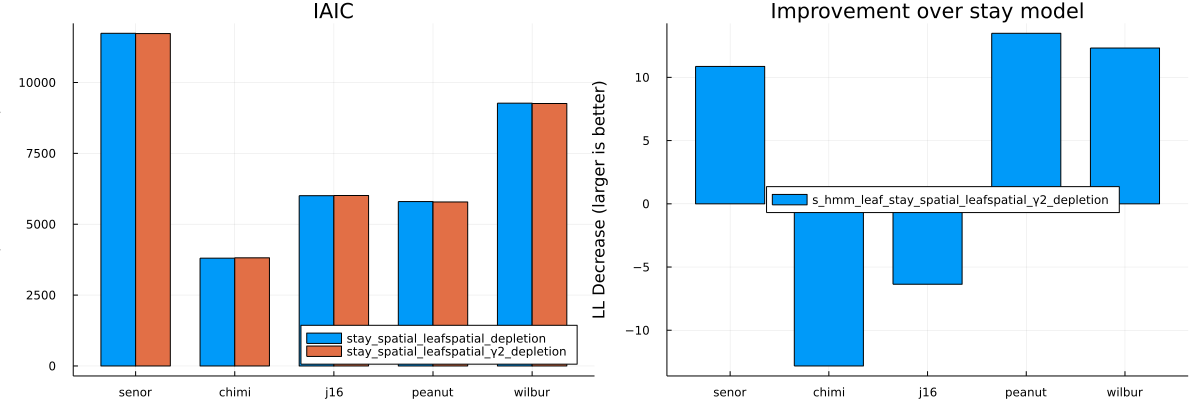

In [17]:
fns = vcat(fns_hmm_stay_depletion[7],fns_hmm_stay_γ2_depletion[5])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][10:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][1:end] for x in fns[2:end]]),
    legend=(0.28,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

# Per-Day Parameter Estimates

AICS:
[11735.191457929388; 3802.352305004656; 6006.540158106328; 5797.881681364887; 9269.660559440297;;]


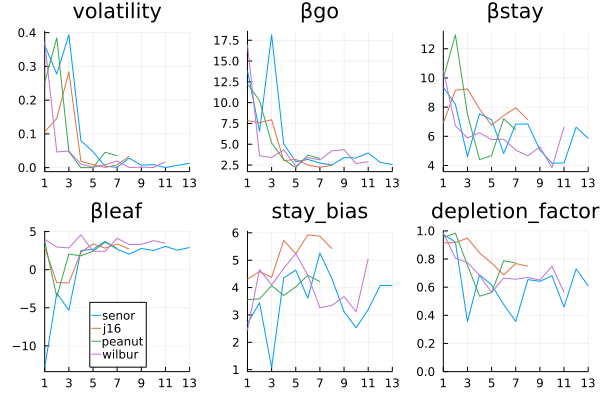

In [18]:
fns = [fns_hmm_stay_depletion[7]]
(results, aics) = load_hmm_results(animals, fns)
x = zeros(5,13,12)
x .= NaN
x[1,1:13,:] = results[(animals[1], fns[1][1])].x
x[2,1:10,:] = results[(animals[2], fns[1][1])].x
x[3,1:8,:] = results[(animals[3], fns[1][1])].x
x[4,1:7,:] = results[(animals[4], fns[1][1])].x
x[5,1:11,:] = results[(animals[5], fns[1][1])].x
varnames = results[(animals[1], fns[1][1])].varnames

p1 = plot(0.5.+0.5.*erf.(x[[1,3,4,5], :, 1]' ./ sqrt(2)),
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[1],
    legend=nothing,
)
xlims!(1,13)
xticks!(1:2:13)

p2 = plot(x[[1,3,4,5], :, 2]',
    labels=nothing,
    title=varnames[2],
)
xlims!(1,13)
xticks!(1:2:13)

p3 = plot(x[[1,3,4,5], :, 3]',
    labels=nothing,
    title=varnames[3],
)
xlims!(1,13)
xticks!(1:2:13)

p4 = plot(x[[1,3,4,5], :, 4]',
    labels=permutedims(animals[[1,3,4,5]]),
    legend=(0.4,0.4),
    title=varnames[4],
)
xlims!(1,13)
xticks!(1:2:13)

p5 = plot(x[[1,3,4,5], :, 5]',
    labels=nothing,
    title=varnames[5],
    legend=(0.4,0.4),
)
xlims!(1,13)
xticks!(1:2:13)

p6 = plot(0.5.+0.5.*erf.(x[[1,3,4,5], :, 12]' ./ sqrt(2)),
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[12],
    legend=nothing,
)
xlims!(1,13)
ylims!(0,1)
xticks!(1:2:13)

println("AICS:")
println(aics)
plot(p1, p2, p3, p4, p5, p6)

![stems](../docs/SpatialBandit_LabeledLeaves.png)

## Stem Biases

Bias is added to the leftmost stem (from the current stem)
- Positive is left
- Negative is right

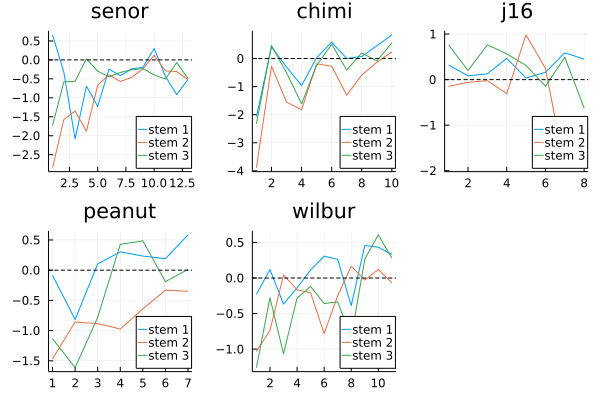

In [19]:
fns = [fns_hmm_stay_depletion[7]]
(results, aics) = load_hmm_results(animals, fns)
plots = []
for animal in animals
    p = plot(results[(animal, fns[1][1])].x[:,6:8], labels=["stem 1" "stem 2" "stem 3"], legend=(0.7, 0.3))
    hline!([0], color="black", style=:dash, label=nothing)
    title!(animal)
    push!(plots, p)
end
plot(plots...)

## Leaf Biases

Bias is added to the leftmost leaf:
- positive bias is left
- negative bias is right

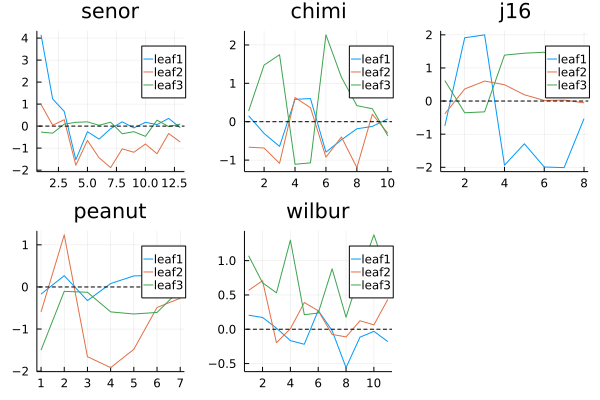

In [20]:
fns = [fns_hmm_stay_depletion[7]]
(results, aics) = load_hmm_results(animals, fns)
plots = []
for animal in animals
    p = plot(results[(animal, fns[1][1])].x[:,9:11], labels=["leaf1" "leaf2" "leaf3"], legend=(0.8, 0.8))
    hline!([0], color="black", style=:dash, label=nothing)
    title!(animal)
    push!(plots, p)
end
plot(plots...)

## Alongside non-depletion results

Below, we're going to plot out the parameters recovered from the non-depletion and depletion versions of the task as a single continus parameter

Dotted lines are non-depletion, and solid lines are depletion results for each animal. Note that animals have different numbers of days, so there isn't necessarily a consistent cutoff.

### Stem Biases

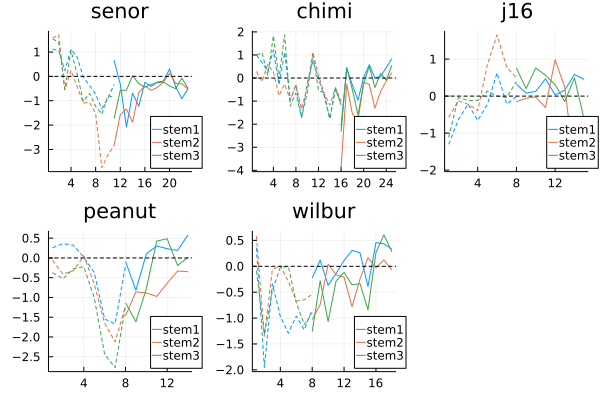

In [46]:
fn = fns_hmm_stay_depletion[7]
(results, aics) = load_hmm_results(animals, [fn])
(results_nondep, aics_nondep) = load_hmm_results(animals, [fn]; depletion=false)
plots = []
colors = permutedims(get_color_palette(:auto, 5)[1:5])
for animal in animals[[1,2,3,4,5]]
    n1 = length(results_nondep[(animal, fn[1])].x[:,1])
    n2 = length(results[(animal, fn[1])].x[:,1])    
    p = plot(1:n1, results_nondep[(animal, fn[1])].x[:,6:8], labels=nothing, legend=(0.8, 0.8), style=:dash, color=colors)
    plot!(n1:n1+n2-1, results[(animal, fn[1])].x[:,6:8], labels=["stem1" "stem2" "stem3"], legend=(0.8, 0.3), color=colors)
    hline!([0], color="black", style=:dash, label=nothing)
    title!(animal)
    xticks!(4:4:n1+n2)
    push!(plots, p)
end
plot(plots...)

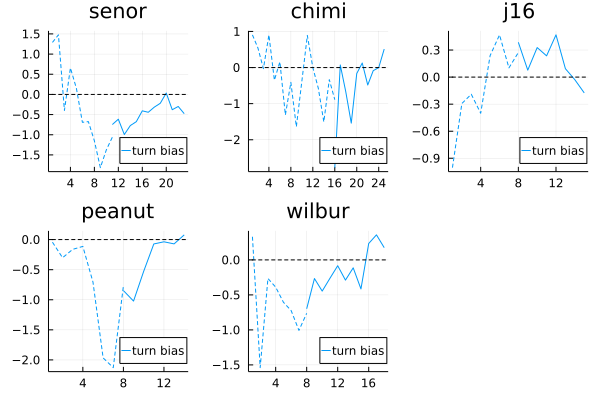

In [45]:
fn = fns_hmm_stay_depletion[5]
(results, aics) = load_hmm_results(animals, [fn])
(results_nondep, aics_nondep) = load_hmm_results(animals, [fn]; depletion=false)
plots = []
colors = permutedims(get_color_palette(:auto, 5)[1:5])
for animal in animals[[1,2,3,4,5]]
    n1 = length(results_nondep[(animal, fn[1])].x[:,1])
    n2 = length(results[(animal, fn[1])].x[:,1])    
    p = plot(1:n1, results_nondep[(animal, fn[1])].x[:,6], labels=nothing, legend=(0.8, 0.8), style=:dash, color=colors)
    plot!(n1:n1+n2-1, results[(animal, fn[1])].x[:,6], labels="turn bias", legend=(0.6, 0.15), color=colors)
    hline!([0], color="black", style=:dash, label=nothing)
    title!(animal)
    xticks!(4:4:n1+n2)
    push!(plots, p)
end
plot(plots...)

### Leaf Biases

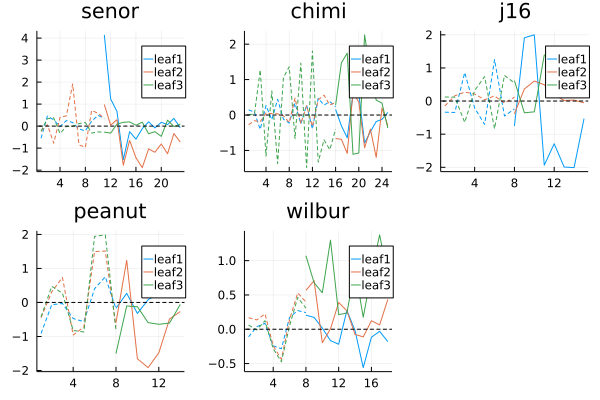

In [48]:
fn = fns_hmm_stay_depletion[7]
(results, aics) = load_hmm_results(animals, [fn])
(results_nondep, aics_nondep) = load_hmm_results(animals, [fn]; depletion=false)
plots = []
colors = permutedims(get_color_palette(:auto, 5)[1:5])
for animal in animals[[1,2,3,4,5]]
    n1 = length(results_nondep[(animal, fn[1])].x[:,1])
    n2 = length(results[(animal, fn[1])].x[:,1])    
    p = plot(1:n1, results_nondep[(animal, fn[1])].x[:,9:11], labels=nothing, legend=(0.8, 0.8), style=:dash, color=colors)
    plot!(n1:n1+n2-1, results[(animal, fn[1])].x[:,9:11], labels=["leaf1" "leaf2" "leaf3"], legend=(0.8, 0.8), color=colors)
    hline!([0], color="black", style=:dash, label=nothing)
    title!(animal)
    xticks!(4:4:n1+n2)
    push!(plots, p)
end
plot(plots...)

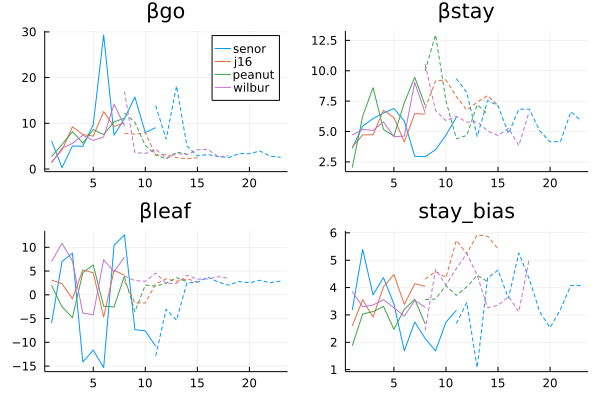

In [56]:
fn = fns_hmm_stay_depletion[7]
(results, aics) = load_hmm_results(animals, [fn])
(results_nondep, aics_nondep) = load_hmm_results(animals, [fn]; depletion=false)
plots = []
colors = permutedims(get_color_palette(:auto, 5)[1:5])

p2 = plot()
varind = 2
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, x1, color=colors[i], label=animal)
    plot!(n1:n1+n2-1, x2, color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

p3 = plot()
varind = 3
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, x1, color=colors[i], label=nothing)
    plot!(n1:n1+n2-1, x2, color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

p4 = plot()
varind = 4
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, x1, color=colors[i], label=nothing)
    plot!(n1:n1+n2-1, x2, color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

p5 = plot()
varind = 5
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, x1, color=colors[i], label=nothing)
    plot!(n1:n1+n2-1, x2, color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

plot(p2, p3, p4, p5)

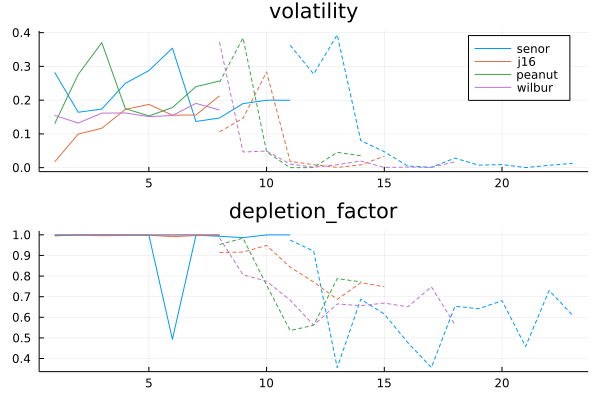

In [54]:
fn = fns_hmm_stay_depletion[7]
(results, aics) = load_hmm_results(animals, [fn])
(results_nondep, aics_nondep) = load_hmm_results(animals, [fn]; depletion=false)
plots = []
colors = permutedims(get_color_palette(:auto, 5)[1:5])

p1 = plot()
varind = 1
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, 0.5.+0.5.*erf.(x1 ./ sqrt(2)), color=colors[i], label=animal)
    plot!(n1:n1+n2-1, 0.5.+0.5.*erf.(x2 ./ sqrt(2)), color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

p6 = plot()
varind = 12
for (i,animal) in enumerate(animals[[1,3,4,5]])
    n1 = length(results_nondep[(animal, fn[1])].x[:,varind])
    n2 = length(results[(animal, fn[1])].x[:,varind])    
    x1 = results_nondep[(animal, fn[1])].x[:,varind]
    x2 = results[(animal, fn[1])].x[:,varind]
    plot!(1:n1, 0.5.+0.5.*erf.(x1 ./ sqrt(2)), color=colors[i], label=nothing)
    plot!(n1:n1+n2-1, 0.5.+0.5.*erf.(x2 ./ sqrt(2)), color=colors[i], style=:dash, label=nothing)
end
title!(results[(animals[1], fn[1])].varnames[varind])

plot(p1, p6, layout=(2,1))